In [15]:
library(tidyverse)

library(grid)
library(gridExtra)
library(patchwork)

source("../evaluation_utils/plots_eda.R")
source("../evaluation_utils/evaluation_funcs.R")

In [16]:
cbPalette <- c("#CC79A7", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00")
condition_palette <- c("#44abe7", "#c55702", "#009E73", "#F0E442")

# Load data

In [17]:
data_path <- "../evaluation_data/multiomics/"
clust_path <- "../evaluation_clusterization_after_correction/real_datasets/multiomics/"
modalities <- c("Transcriptomics", "Proteomics", "Metabolomics")
donor_levels <- c("D5", "D6", "F7", "M8")

read_feature_matrix <- function(path) {
    read.csv(path, sep = "	", header = TRUE, row.names = 1, check.names = FALSE)
}

load_modality_data <- function(modality) {
    metadata <- read.csv(
        paste0(data_path, "before/", modality, "/metadata.tsv"),
        sep = "	", header = TRUE, check.names = FALSE
    ) %>%
        mutate(
            condition = factor(condition, levels = donor_levels),
            lab = factor(lab),
            batch_code = factor(batch_code),
            platform = factor(platform),
            rep = factor(rep)
        )
    rownames(metadata) <- metadata$file

    central_uncorrected <- read_feature_matrix(
        paste0(data_path, "before/", modality, "/central_intensities_log_UNION.tsv")
    )
    central_corrected <- read_feature_matrix(
        paste0(data_path, "after/", modality, "/intensities_log_Rcorrected_UNION.tsv")
    )

    fed_path <- paste0(data_path, "after/", modality, "/FedApp_corrected_data.tsv")
    fed_corrected <- if (file.exists(fed_path)) read_feature_matrix(fed_path) else NULL

    shared_features <- intersect(rownames(central_uncorrected), rownames(central_corrected))
    central_uncorrected <- central_uncorrected[shared_features, rownames(metadata), drop = FALSE]
    central_corrected <- central_corrected[shared_features, rownames(metadata), drop = FALSE]

    if (!is.null(fed_corrected)) {
        fed_corrected <- fed_corrected[shared_features, rownames(metadata), drop = FALSE]
    }

    list(
        central_uncorrected = central_uncorrected,
        central_corrected = central_corrected,
        fed_corrected = fed_corrected,
        metadata = metadata
    )
}

load_combined_data <- function() {
    metadata <- read.csv(
        paste0(clust_path, "prepared/metadata.tsv"),
        sep = "	", header = TRUE, check.names = FALSE
    ) %>%
        mutate(
            condition = factor(condition, levels = donor_levels),
            lab = factor(lab)
        )
    rownames(metadata) <- metadata$file

    central_uncorrected <- read_feature_matrix(paste0(clust_path, "prepared/before_matrix.tsv"))
    central_corrected <- read_feature_matrix(paste0(clust_path, "prepared/corrected_matrix.tsv"))
    fed_path <- paste0(clust_path, "prepared/corrected_fedrbe_matrix.tsv")
    fed_corrected <- if (file.exists(fed_path)) read_feature_matrix(fed_path) else NULL

    central_uncorrected <- central_uncorrected[, rownames(metadata), drop = FALSE]
    central_corrected <- central_corrected[rownames(central_uncorrected), rownames(metadata), drop = FALSE]

    if (!is.null(fed_corrected)) {
        fed_corrected <- fed_corrected[rownames(central_uncorrected), rownames(metadata), drop = FALSE]
    }

    list(
        central_uncorrected = central_uncorrected,
        central_corrected = central_corrected,
        fed_corrected = fed_corrected,
        metadata = metadata
    )
}

multiomics_data <- setNames(lapply(modalities, load_modality_data), modalities)
combined <- load_combined_data()

dataset_summary <- bind_rows(
    lapply(names(multiomics_data), function(modality) {
        data <- multiomics_data[[modality]]
        tibble(
            dataset = modality,
            features = nrow(data$central_uncorrected),
            samples = ncol(data$central_uncorrected),
            batches = n_distinct(data$metadata$lab),
            donors = n_distinct(data$metadata$condition),
            fedrbe_available = !is.null(data$fed_corrected)
        )
    }),
    tibble(
        dataset = "All modalities",
        features = nrow(combined$central_uncorrected),
        samples = ncol(combined$central_uncorrected),
        batches = n_distinct(combined$metadata$lab),
        donors = n_distinct(combined$metadata$condition),
        fedrbe_available = !is.null(combined$fed_corrected)
    )
)

dataset_summary

dataset,features,samples,batches,donors,fedrbe_available
<chr>,<int>,<int>,<int>,<int>,<lgl>
Transcriptomics,26907,72,4,4,TRUE
Proteomics,3489,72,4,4,TRUE
Metabolomics,71,72,5,4,TRUE
All modalities,30467,72,4,4,TRUE


# Checks

## Diagnostic plots

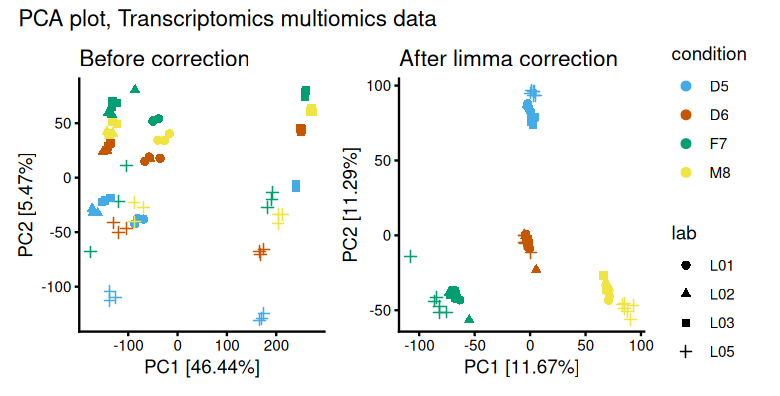

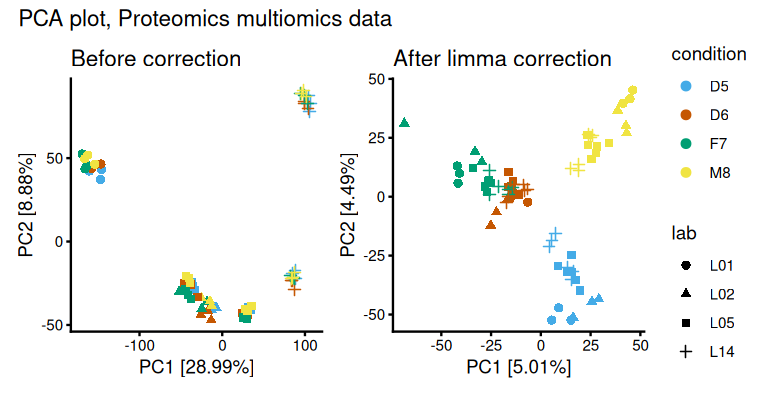

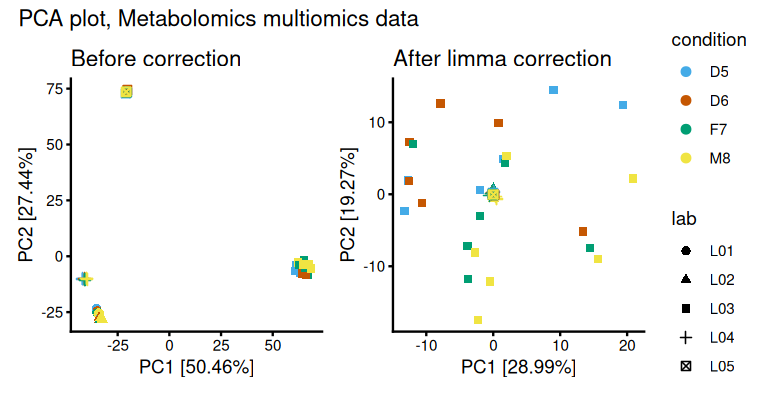

In [18]:
for (modality in modalities) {
    data <- multiomics_data[[modality]]

    pca_plot_uncorrected <- pca_plot(data$central_uncorrected, data$metadata,
        title = "Before correction",
        quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
        show_legend = FALSE, cbPalette = condition_palette)
    pca_plot_corrected <- pca_plot(data$central_corrected, data$metadata,
        title = "After limma correction",
        quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
        show_legend = TRUE, cbPalette = condition_palette)

    layout <- (pca_plot_uncorrected + pca_plot_corrected)
    layout <- layout + plot_annotation(paste("PCA plot,", modality, "multiomics data"))
    options(repr.plot.width = 6.5, repr.plot.height = 3.3)
    print(layout)
}

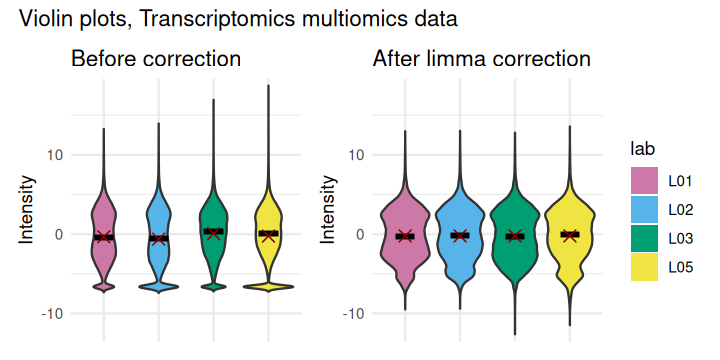

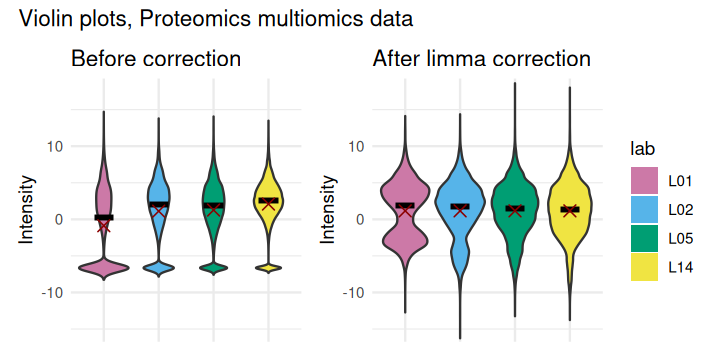

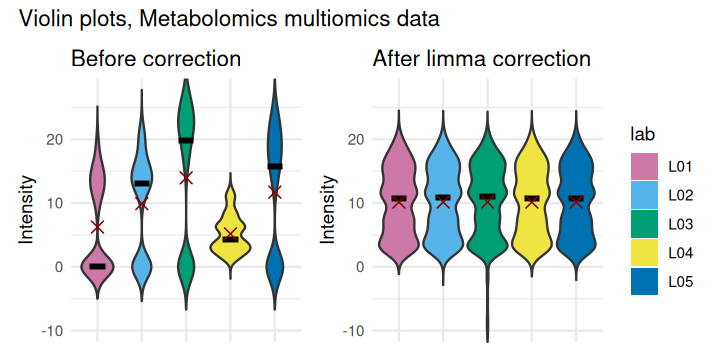

In [19]:
for (modality in modalities) {
    data <- multiomics_data[[modality]]

    y_min <- min(data$central_uncorrected, data$central_corrected, na.rm = TRUE)
    y_max <- max(data$central_uncorrected, data$central_corrected, na.rm = TRUE)
    y_limits <- c(y_min, y_max)

    boxplots_uncorrected <- boxplot_plot_groupped(data$central_uncorrected, data$metadata,
        title = "Before correction",
        quantitativeColumnName = "file",
        color_col = "lab", remove_xnames = TRUE, show_legend = FALSE,
        y_limits = y_limits, cbPalette = cbPalette)
    boxplots_corrected <- boxplot_plot_groupped(data$central_corrected, data$metadata,
        title = "After limma correction",
        quantitativeColumnName = "file",
        color_col = "lab", remove_xnames = TRUE,
        y_limits = y_limits, cbPalette = cbPalette)

    layout <- (boxplots_uncorrected + boxplots_corrected)
    layout <- layout + plot_annotation(paste("Violin plots,", modality, "multiomics data"))
    options(repr.plot.width = 6, repr.plot.height = 3)
    print(layout)
}

### Combined all-modality plots

The combined matrix is the equal-weight, row-z-scored matrix prepared for all-three-modality k-means.

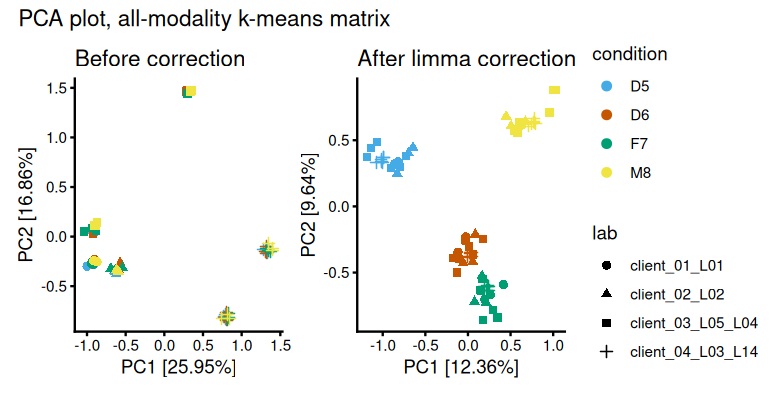

In [20]:
pca_plot_uncorrected <- pca_plot(combined$central_uncorrected, combined$metadata,
    title = "Before correction",
    quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
    show_legend = FALSE, cbPalette = condition_palette)
pca_plot_corrected <- pca_plot(combined$central_corrected, combined$metadata,
    title = "After limma correction",
    quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
    show_legend = TRUE, cbPalette = condition_palette)

layout <- (pca_plot_uncorrected + pca_plot_corrected)
layout <- layout + plot_annotation("PCA plot, all-modality k-means matrix")
options(repr.plot.width = 6.5, repr.plot.height = 3.3)
layout

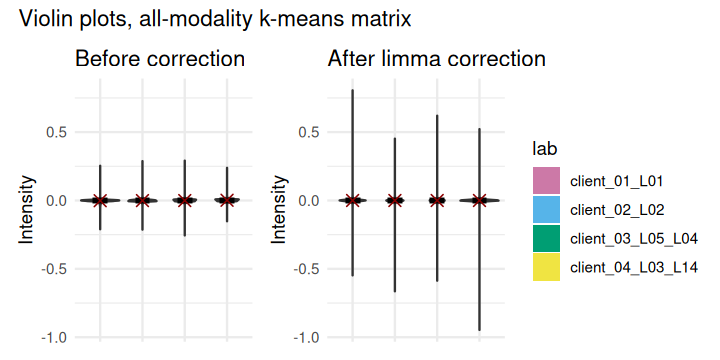

In [21]:
y_min <- min(combined$central_uncorrected, combined$central_corrected, na.rm = TRUE)
y_max <- max(combined$central_uncorrected, combined$central_corrected, na.rm = TRUE)
y_limits <- c(y_min, y_max)

boxplots_uncorrected <- boxplot_plot_groupped(combined$central_uncorrected, combined$metadata,
    title = "Before correction",
    quantitativeColumnName = "file",
    color_col = "lab", remove_xnames = TRUE, show_legend = FALSE,
    y_limits = y_limits, cbPalette = cbPalette)
boxplots_corrected <- boxplot_plot_groupped(combined$central_corrected, combined$metadata,
    title = "After limma correction",
    quantitativeColumnName = "file",
    color_col = "lab", remove_xnames = TRUE,
    y_limits = y_limits, cbPalette = cbPalette)

layout <- (boxplots_uncorrected + boxplots_corrected)
layout <- layout + plot_annotation("Violin plots, all-modality k-means matrix")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

## Linear model per variable

Following batch effect correction, the percentage of variance explained by the condition should be greater than the batch.

In [22]:
library(variancePartition)

In [23]:
form <- ~ condition + lab

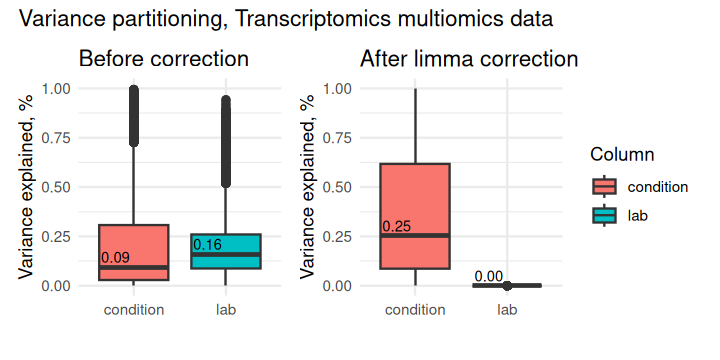

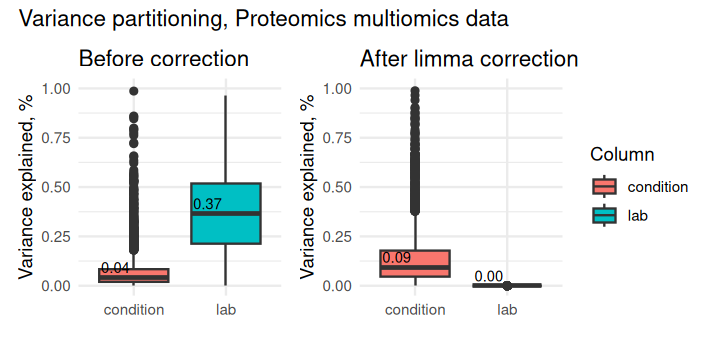

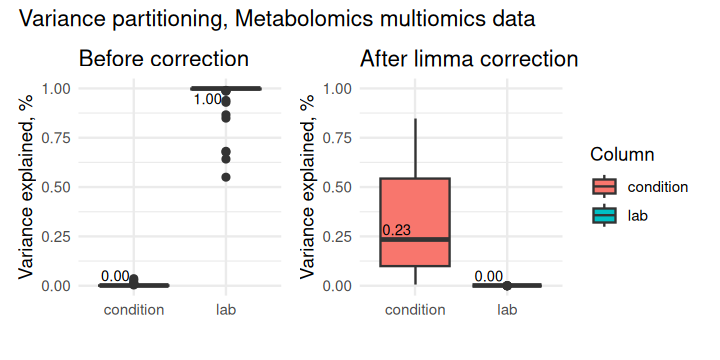

In [24]:
for (modality in modalities) {
    data <- multiomics_data[[modality]]

    lmpv_plot_corrected <- lmpv_plot(data$central_corrected, data$metadata,
        title = "After limma correction", form = form)
    lmpv_plot_uncorrected <- lmpv_plot(data$central_uncorrected, data$metadata,
        title = "Before correction", show_legend = FALSE, form = form)

    layout <- (lmpv_plot_uncorrected + lmpv_plot_corrected)
    layout <- layout + plot_annotation(paste("Variance partitioning,", modality, "multiomics data"))
    options(repr.plot.width = 6, repr.plot.height = 3)
    print(layout)
}

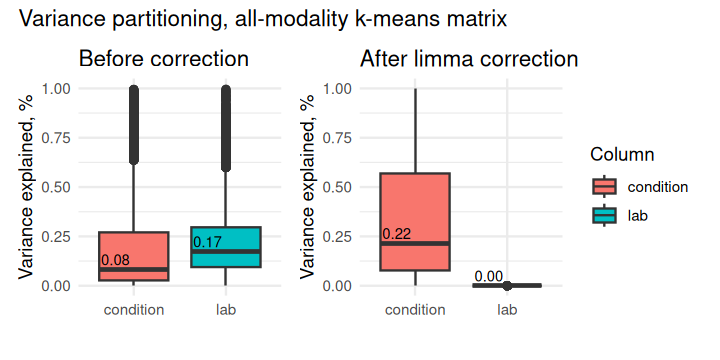

In [25]:
lmpv_plot_corrected <- lmpv_plot(combined$central_corrected, combined$metadata,
    title = "After limma correction", form = form)
lmpv_plot_uncorrected <- lmpv_plot(combined$central_uncorrected, combined$metadata,
    title = "Before correction", show_legend = FALSE, form = form)

layout <- (lmpv_plot_uncorrected + lmpv_plot_corrected)
layout <- layout + plot_annotation("Variance partitioning, all-modality k-means matrix")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

## K-means ARI plot

ARI results come from `evaluation_clusterization_after_correction/real_datasets/multiomics/metrics/metrics_ari.tsv`, computed by the federated k-means pipeline on the equal-weight three-modality combined matrix. **Donor ARI** (`condition` target) should approach 1 after correction; **client ARI** should approach 0.

Dataset,Target,K,Method,ARI,N,matrix,target
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<fct>,<fct>
multiomics,condition,4,multiomics_condition_BC_Cntrl_4cls,-0.0408377,72,Before correction,donor
multiomics,condition,4,multiomics_condition_AC_Cntrl_4cls,1.0000000,72,After limma correction,donor
multiomics,condition,4,multiomics_condition_AC_FedRBE_Cntrl_4cls,1.0000000,72,After FedRBE correction,donor
multiomics,client,4,multiomics_client_BC_Cntrl_4cls,0.7125506,72,Before correction,client
multiomics,client,4,multiomics_client_AC_Cntrl_4cls,-0.0408377,72,After limma correction,client
multiomics,client,4,multiomics_client_AC_FedRBE_Cntrl_4cls,-0.0408377,72,After FedRBE correction,client


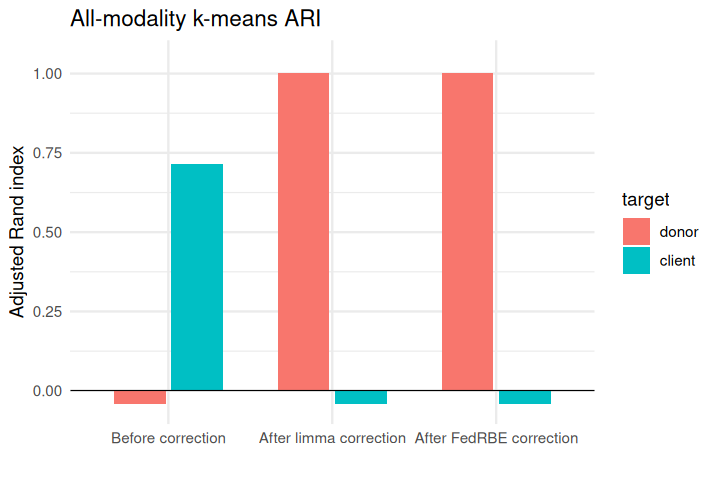

In [26]:
metrics <- readr::read_tsv(paste0(clust_path, "metrics/metrics_ari.tsv"), show_col_types = FALSE) %>%
    mutate(
        matrix = case_when(
            grepl("_BC_", Method) ~ "Before correction",
            grepl("_AC_FedRBE_", Method) ~ "After FedRBE correction",
            grepl("_AC_", Method) ~ "After limma correction",
            TRUE ~ Method
        ),
        matrix = factor(matrix, levels = c("Before correction", "After limma correction", "After FedRBE correction")),
        target = recode(Target, condition = "donor"),
        target = factor(target, levels = c("donor", "client"))
    )

ari_plot <- ggplot(metrics, aes(x = matrix, y = ARI, fill = target)) +
    geom_col(position = position_dodge(width = 0.7), width = 0.62) +
    geom_hline(yintercept = 0, linewidth = 0.25) +
    coord_cartesian(ylim = c(min(-0.05, min(metrics$ARI, na.rm = TRUE)), 1.05)) +
    theme_minimal() +
    labs(title = "All-modality k-means ARI", x = "", y = "Adjusted Rand index", fill = "target")

options(repr.plot.width = 6, repr.plot.height = 4)
ari_plot
metrics

## FedRBE / FC app plots

If the FeatureCloud app outputs are present (`FedApp_corrected_data.tsv` and `prepared/corrected_fedrbe_matrix.tsv`), generate the same before-vs-FedRBE diagnostics using the shared plotting helpers.

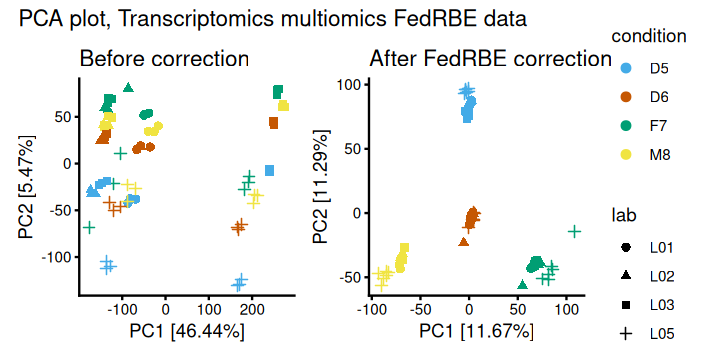

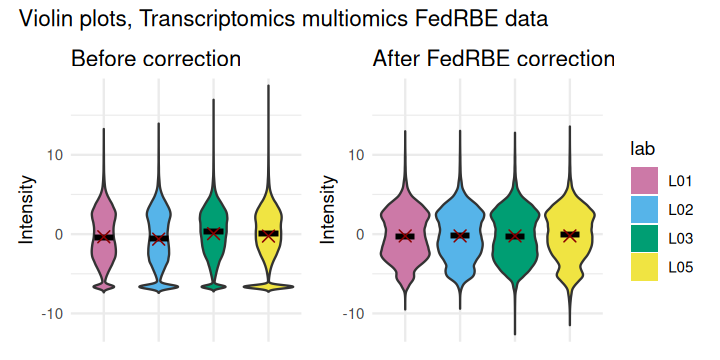

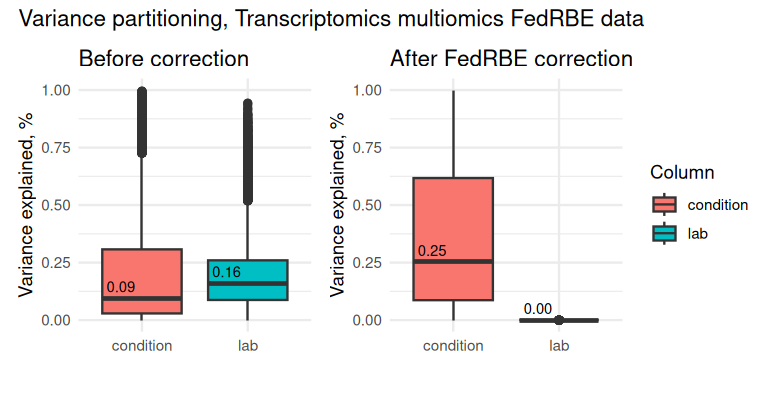

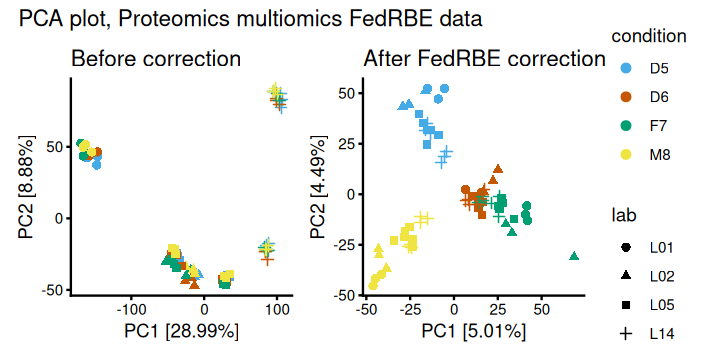

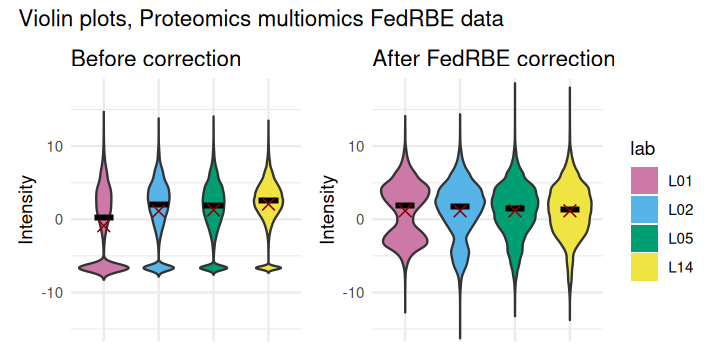

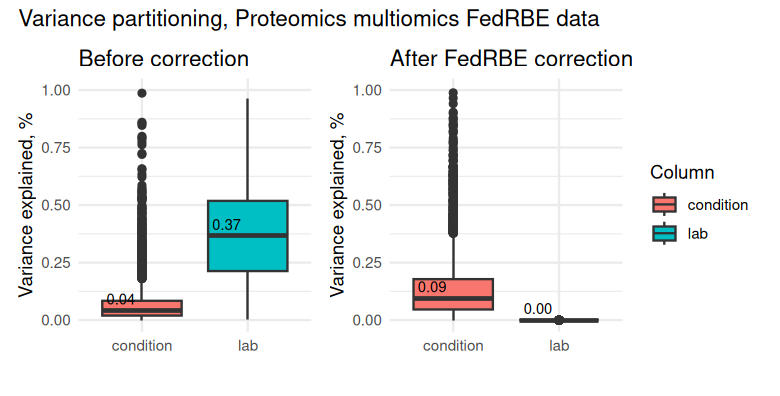

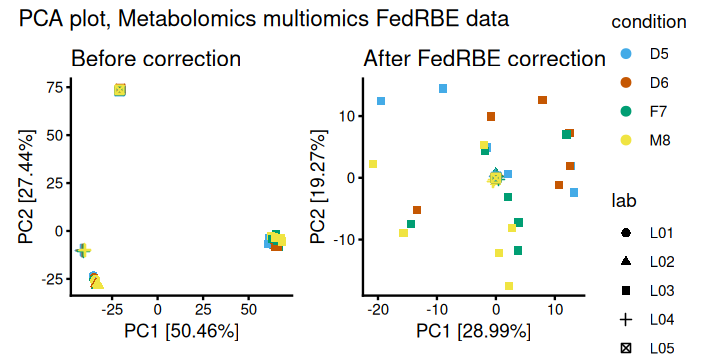

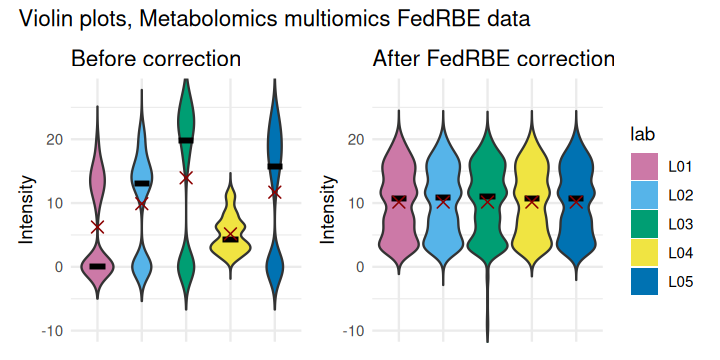

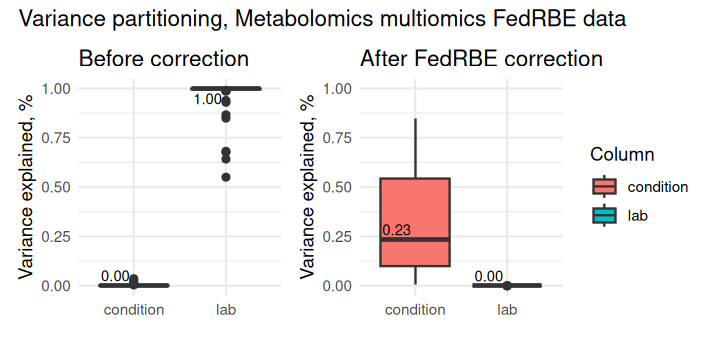

In [ ]:
for (modality in modalities) {
    data <- multiomics_data[[modality]]
    if (is.null(data$fed_corrected)) {
        message("Skipping FedRBE plots for ", modality, ": FedApp_corrected_data.tsv not found")
        next
    }

    pca_plot_uncorrected <- pca_plot(data$central_uncorrected, data$metadata,
        title = "Before correction",
        quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
        show_legend = FALSE, cbPalette = condition_palette)
    pca_plot_fed <- pca_plot(data$fed_corrected, data$metadata,
        title = "After FedRBE correction",
        quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
        show_legend = TRUE, cbPalette = condition_palette)

    layout <- (pca_plot_uncorrected + pca_plot_fed)
    layout <- layout + plot_annotation(paste("PCA plot,", modality, "multiomics FedRBE data"))
    options(repr.plot.width = 6.5, repr.plot.height = 3.3)
    print(layout)

    y_min <- min(data$central_uncorrected, data$fed_corrected, na.rm = TRUE)
    y_max <- max(data$central_uncorrected, data$fed_corrected, na.rm = TRUE)
    y_limits <- c(y_min, y_max)

    boxplots_uncorrected <- boxplot_plot_groupped(data$central_uncorrected, data$metadata,
        title = "Before correction",
        quantitativeColumnName = "file",
        color_col = "lab", remove_xnames = TRUE, show_legend = FALSE,
        y_limits = y_limits, cbPalette = cbPalette)
    boxplots_fed <- boxplot_plot_groupped(data$fed_corrected, data$metadata,
        title = "After FedRBE correction",
        quantitativeColumnName = "file",
        color_col = "lab", remove_xnames = TRUE,
        y_limits = y_limits, cbPalette = cbPalette)

    layout <- (boxplots_uncorrected + boxplots_fed)
    layout <- layout + plot_annotation(paste("Violin plots,", modality, "multiomics FedRBE data"))
    options(repr.plot.width = 6, repr.plot.height = 3)
    print(layout)

    lmpv_plot_fed <- lmpv_plot(data$fed_corrected, data$metadata,
        title = "After FedRBE correction", form = form)
    lmpv_plot_uncorrected <- lmpv_plot(data$central_uncorrected, data$metadata,
        title = "Before correction", show_legend = FALSE, form = form)

    layout <- (lmpv_plot_uncorrected + lmpv_plot_fed)
    layout <- layout + plot_annotation(paste("Variance partitioning,", modality, "multiomics FedRBE data"))
    options(repr.plot.width = 6, repr.plot.height = 3)
    print(layout)
}

if (!is.null(combined$fed_corrected)) {
    pca_plot_uncorrected <- pca_plot(combined$central_uncorrected, combined$metadata,
        title = "Before correction",
        quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
        show_legend = FALSE, cbPalette = condition_palette)
    pca_plot_fed <- pca_plot(combined$fed_corrected, combined$metadata,
        title = "After FedRBE correction",
        quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
        show_legend = TRUE, cbPalette = condition_palette)

    layout <- (pca_plot_uncorrected + pca_plot_fed)
    layout <- layout + plot_annotation("PCA plot, all-modality FedRBE k-means matrix")
    options(repr.plot.width = 6.5, repr.plot.height = 3.3)
    print(layout)

    y_min <- min(combined$central_uncorrected, combined$fed_corrected, na.rm = TRUE)
    y_max <- max(combined$central_uncorrected, combined$fed_corrected, na.rm = TRUE)
    y_limits <- c(y_min, y_max)

    boxplots_uncorrected <- boxplot_plot_groupped(combined$central_uncorrected, combined$metadata,
        title = "Before correction",
        quantitativeColumnName = "file",
        color_col = "lab", remove_xnames = TRUE, show_legend = FALSE,
        y_limits = y_limits, cbPalette = cbPalette)
    boxplots_fed <- boxplot_plot_groupped(combined$fed_corrected, combined$metadata,
        title = "After FedRBE correction",
        quantitativeColumnName = "file",
        color_col = "lab", remove_xnames = TRUE,
        y_limits = y_limits, cbPalette = cbPalette)

    layout <- (boxplots_uncorrected + boxplots_fed)
    layout <- layout + plot_annotation("Violin plots, all-modality FedRBE k-means matrix")
    options(repr.plot.width = 6, repr.plot.height = 3)
    print(layout)

    lmpv_plot_fed <- lmpv_plot(combined$fed_corrected, combined$metadata,
        title = "After FedRBE correction", form = form)
    lmpv_plot_uncorrected <- lmpv_plot(combined$central_uncorrected, combined$metadata,
        title = "Before correction", show_legend = FALSE, form = form)

    layout <- (lmpv_plot_uncorrected + lmpv_plot_fed)
    layout <- layout + plot_annotation("Variance partitioning, all-modality FedRBE k-means matrix")
    options(repr.plot.width = 6, repr.plot.height = 3)
    print(layout)
}

# Session info

In [ ]:
sessionInfo()